[2026-08-02 17:22:50] [info     ] 计算因子，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
因子每日原始覆盖率统计：
count    242.000000
mean       0.719074
std        0.092830
min        0.375000
25%        0.662500
50%        0.713000
75%        0.788500
max        0.916000
Name: factor, dtype: float64
覆盖率最低的10个交易日：
date
2024-02-05    0.375
2024-02-02    0.472
2024-02-06    0.485
2024-01-31    0.488
2024-02-01    0.498
2024-01-30    0.519
2024-02-07    0.528
2024-01-22    0.545
2024-01-23    0.547
2024-02-08    0.553
Name: factor, dtype: float64
[2026-08-02 17:24:07] [info     ] 读取因子库，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-08-02 17:24:07] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-08-02 17:24:11] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-08-02 17:24:11] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-08-02 17:24:11] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-08-02 17:24:11] [info     ] ========== 

时段,IC
2024-01-15~2024-02-08,0.0038
2024-09-24~2024-10-08,0.0500

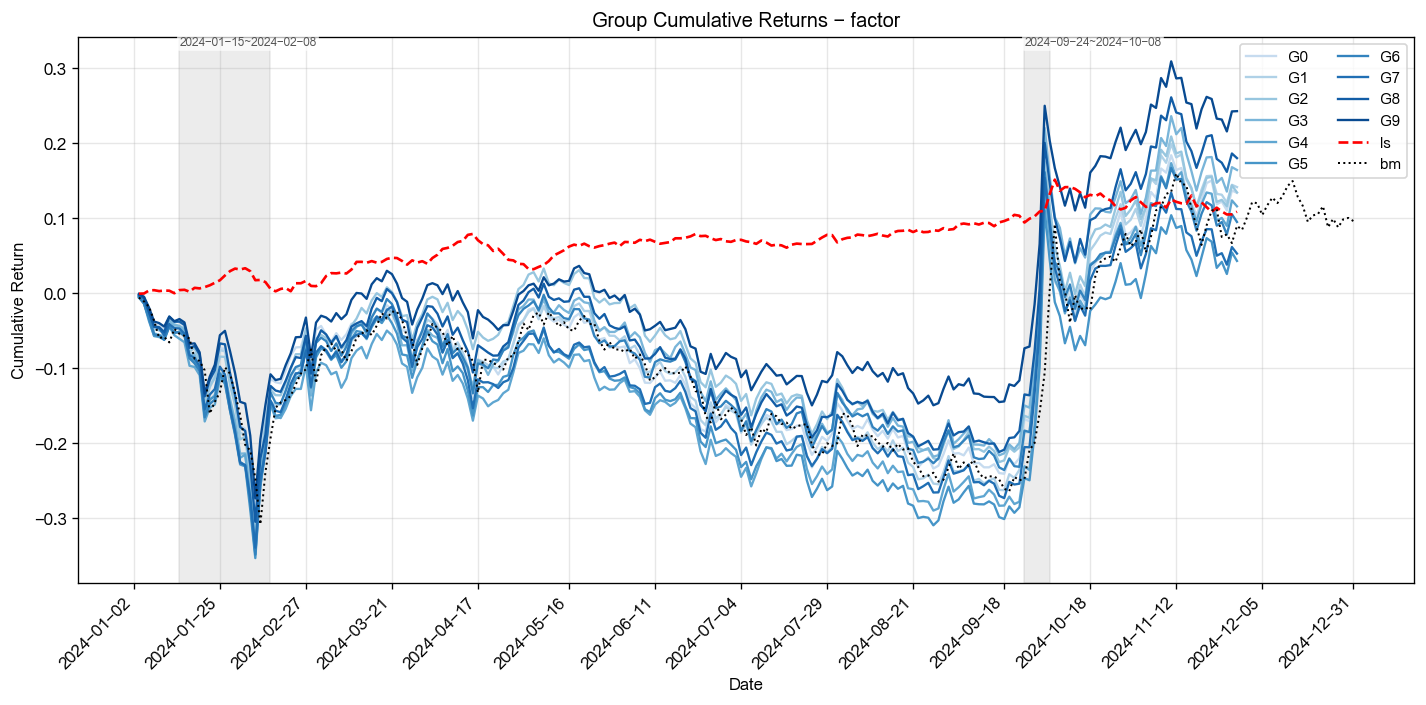
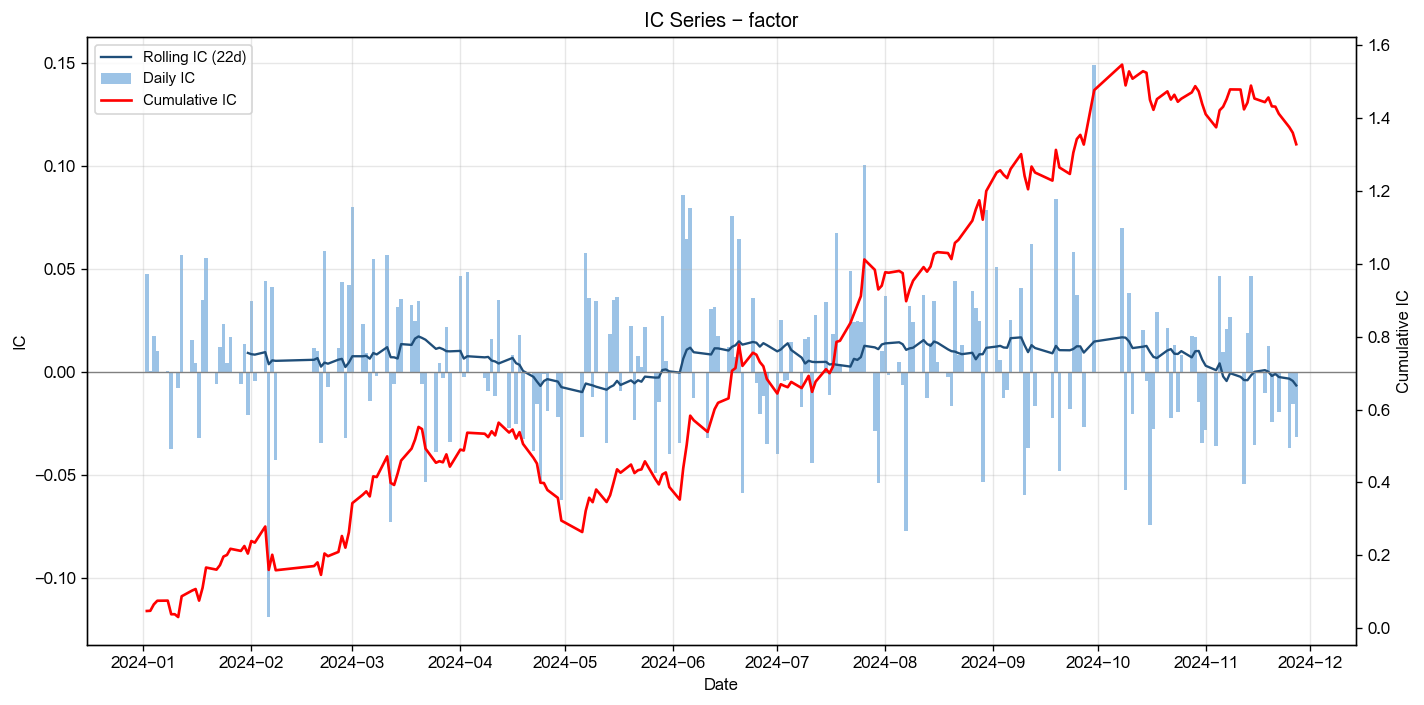
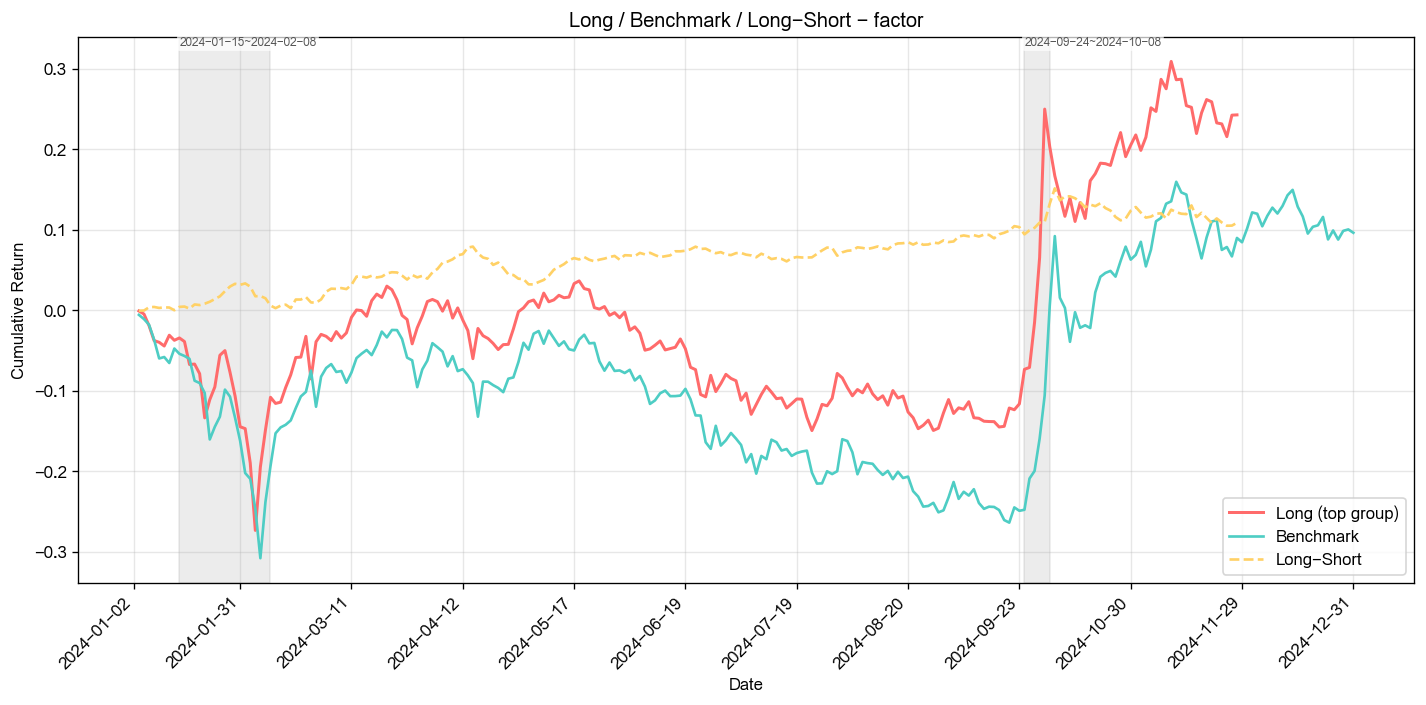
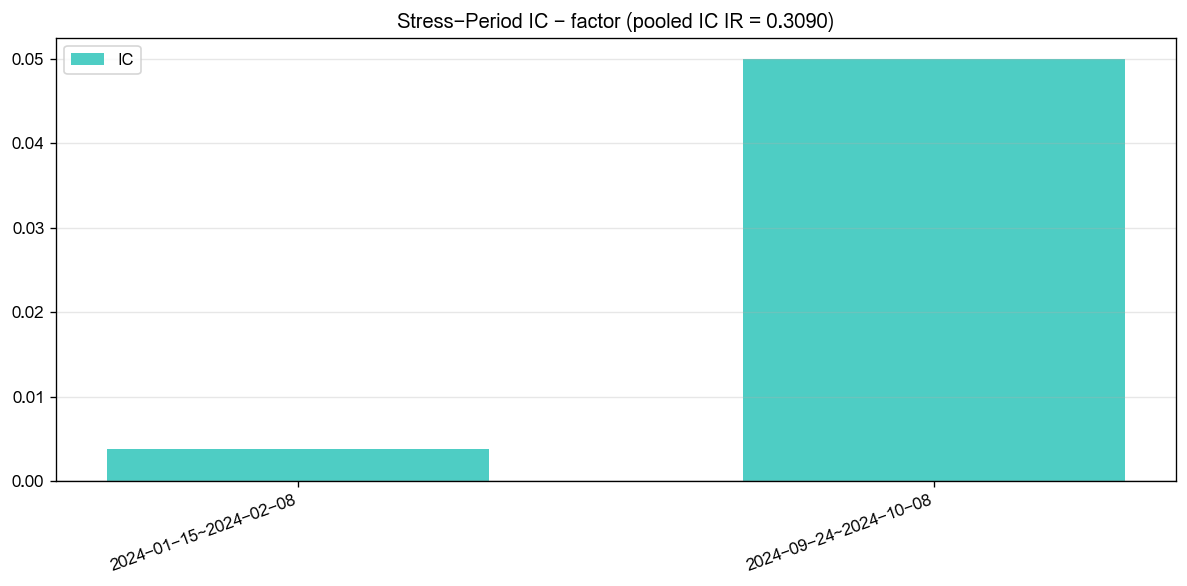
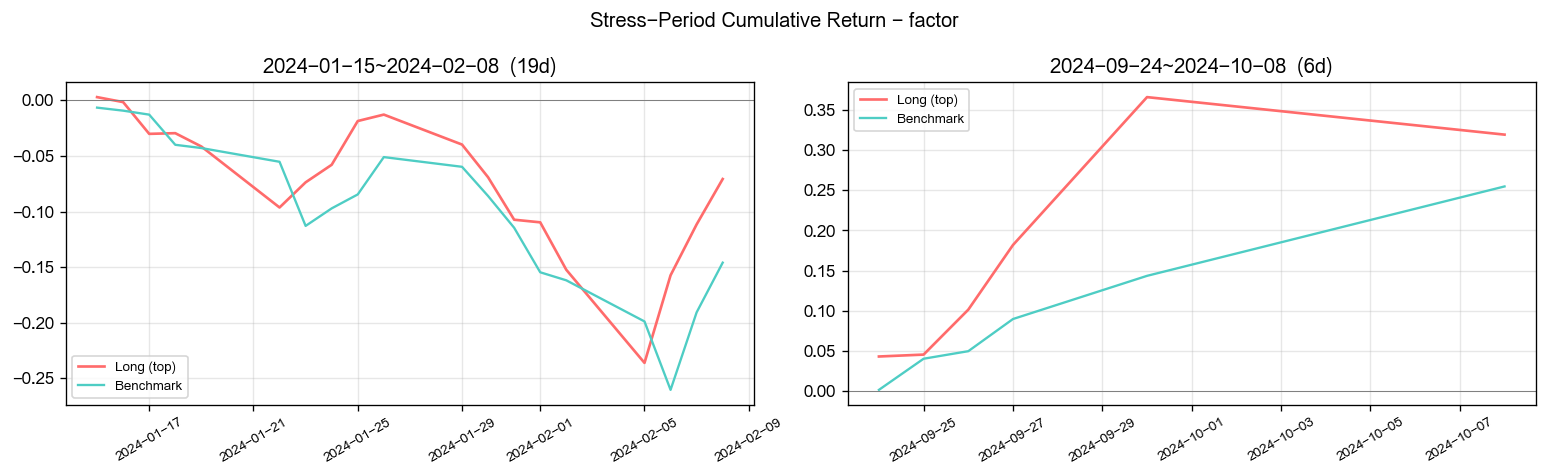

[2026-08-02 17:24:26] [info     ] ========== 因子池回归 ==========
[2026-08-02 17:24:27] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-08-02 17:24:28] [info     ] 获取收益率数据, 耗时: 1.4769 秒
[2026-08-02 17:24:29] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.9327 秒
[2026-08-02 17:24:29] [info     ] 统计 回归结果, 耗时: 0.0896 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.9355,0.0446,0.0230,1.0000
2,amount,1.7215,0.0187,0.0109,1.0000
3,netflow_amount_rate_main,1.5684,0.0101,0.0064,1.0000
4,gross_profit_rate_ttm,1.5043,0.0069,0.0046,1.0000
5,netflow_amount_main,1.4719,0.0248,0.0168,1.0000
6,net_profit_rate_ttm,1.4494,0.0040,0.0028,0.8000
7,pb,1.4118,0.0096,0.0068,1.0000
8,bias_20,1.3965,0.0289,0.0207,0.9000
9,cci_14,1.3824,0.0338,0.0245,1.0000
10,volume,1.3296,0.0136,0.0103,1.0000

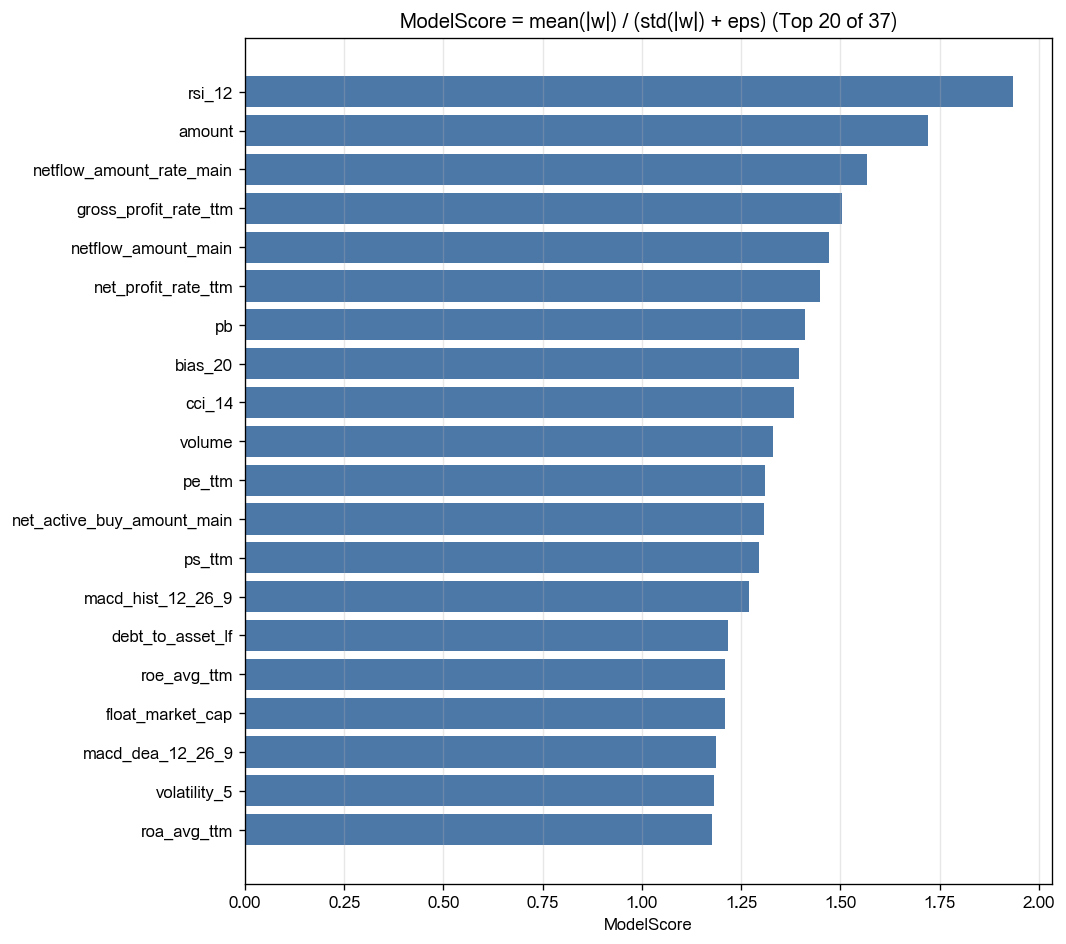
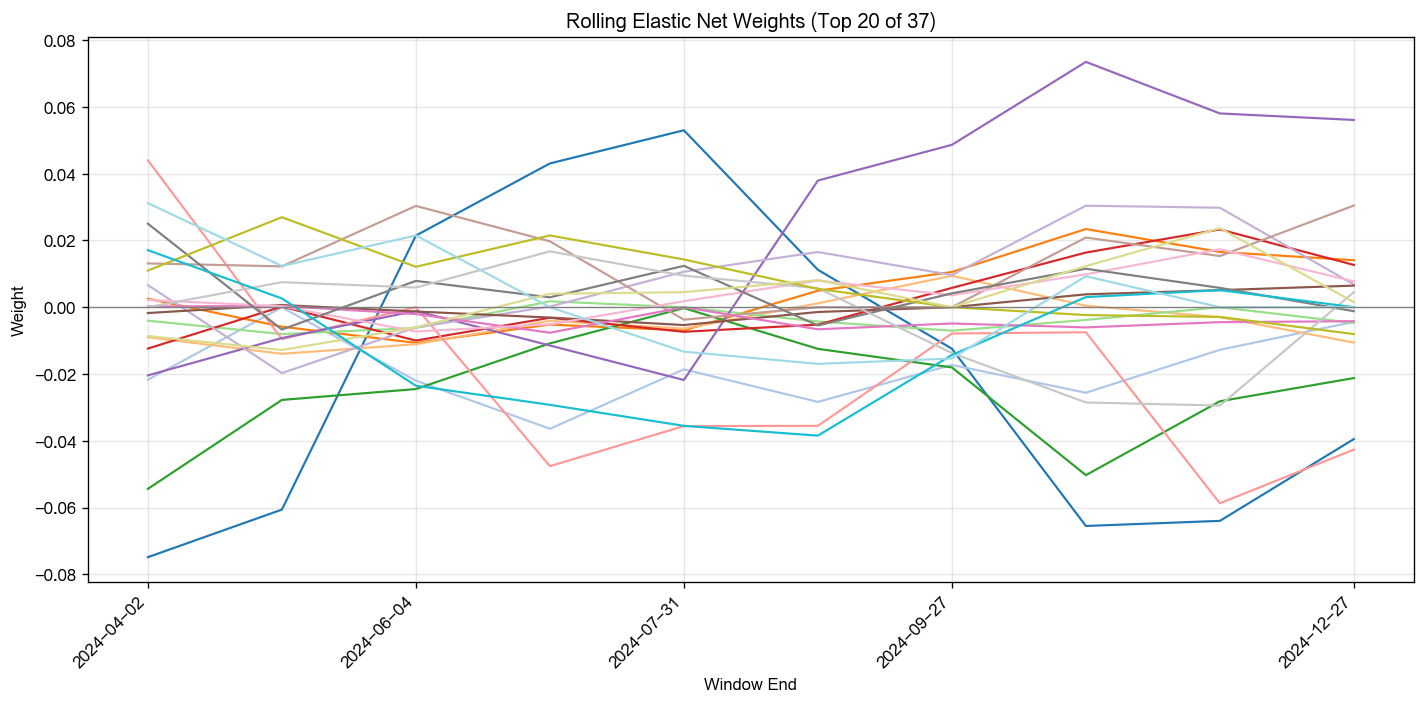
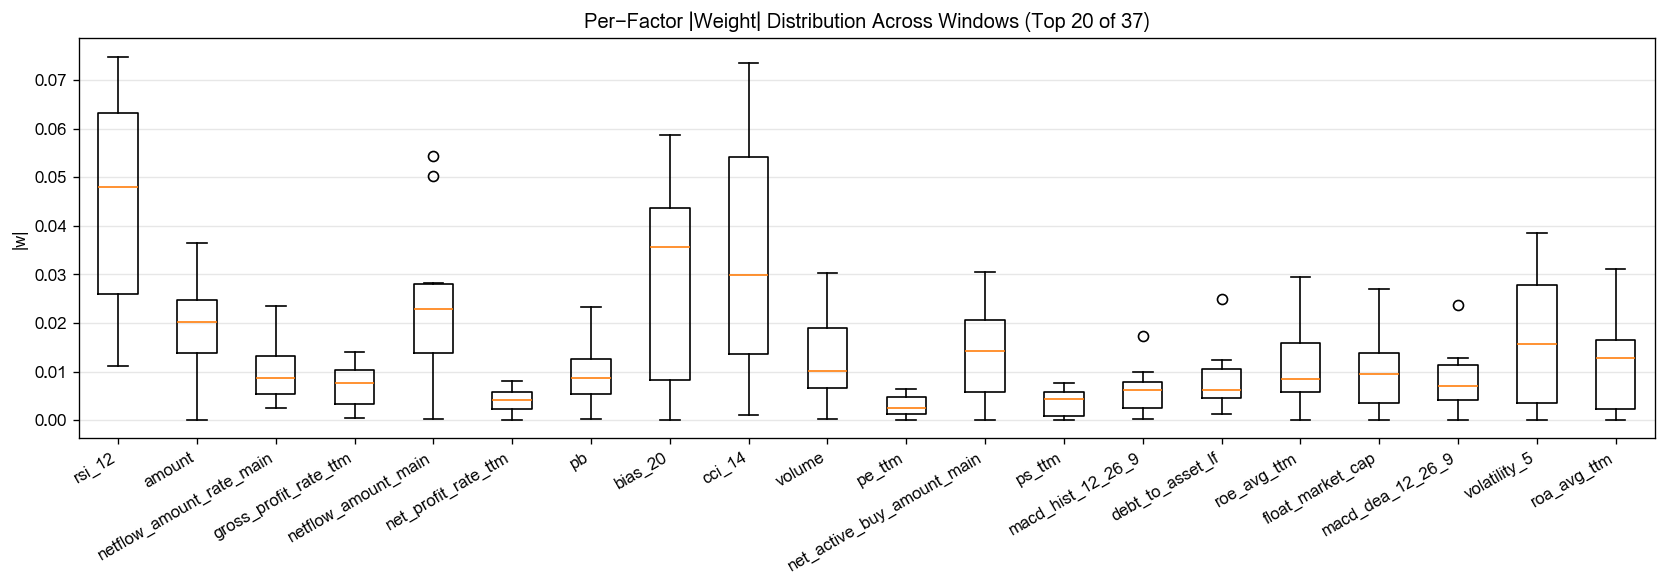
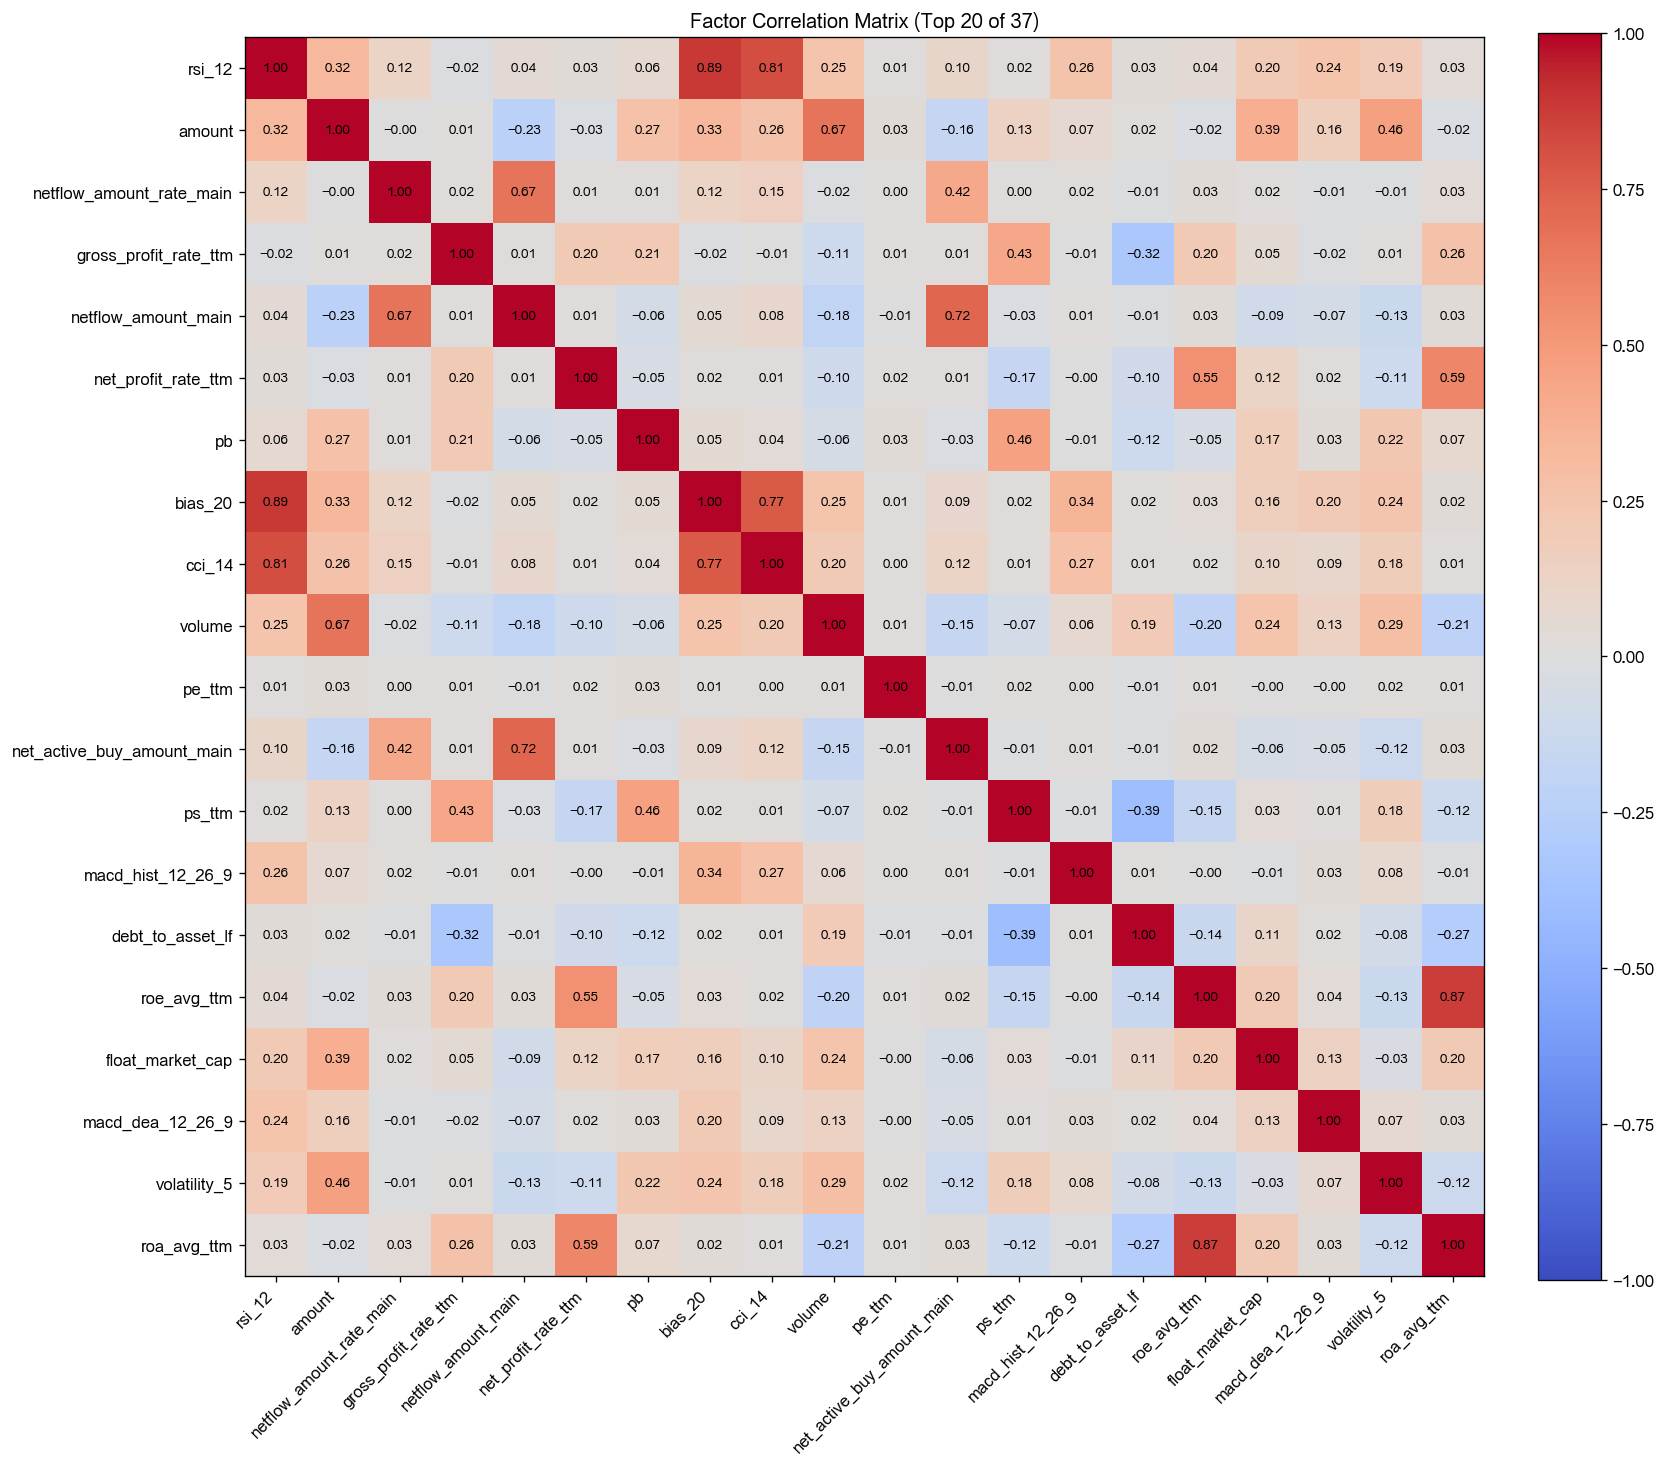

[2026-08-02 17:24:33] [warning  ] 返回的Outputs实例(size=35386534) 大于 64K, 将不会被缓存
[2026-08-02 17:24:33] [info     ] bigalpha_eval.v4 运行完成 [22.231s].


In [1]:
def main(datasources, start_date, end_date):
    """
    改进方向性订单簿因子

    核心组成：
    1. 固定金额买入/卖出价格冲击
    2. 订单簿方向性不平衡
    3. 深浅档斜率不平衡
    4. 订单簿凸性不平衡
    5. 极端流动性冲击后的恢复/持续性

    最终返回：
        date, instrument, factor
    """
    import re
    import numpy as np
    import pandas as pd
    import dai

    bar1m = datasources["bar1m"]

    # 防止物理表名异常
    if not re.fullmatch(r"[A-Za-z_][A-Za-z0-9_.]*", bar1m):
        raise ValueError(f"非法的 bar1m 数据表名: {bar1m}")

    eps = 1e-12

    sql = f"""
    WITH raw_depth AS (
        SELECT
            date AS snapshot_time,
            CAST(date AS DATE) AS trade_date,
            instrument,

            (ask_price1 + bid_price1) / 2.0 AS midprice,

            ask_price1,
            ask_price2,
            ask_price3,
            ask_price4,
            ask_price5,

            bid_price1,
            bid_price2,
            bid_price3,
            bid_price4,
            bid_price5,

            ask_volume1,
            ask_volume2,
            ask_volume3,
            ask_volume4,
            ask_volume5,

            bid_volume1,
            bid_volume2,
            bid_volume3,
            bid_volume4,
            bid_volume5

        FROM {bar1m}

        WHERE ask_price1 > 0
          AND bid_price1 > 0
          AND ask_price1 >= bid_price1
          AND ask_volume1 >= 0
          AND bid_volume1 >= 0
    ),

    /*
    每个快照分别计算10万、50万和200万元的执行价格。

    固定金额先按照中间价换算成目标股数：
        target_qty = q_value / midprice

    随后逐档消耗盘口数量。最后一档只取实际需要的部分，
    避免原实现中“只需要部分第二档，却把全部第二档纳入”
    所产生的档位跳跃。
    */
    depth_by_q AS (
        SELECT
            d.*,
            q.q_value,
            q.q_value / NULLIF(d.midprice, 0) AS target_qty

        FROM raw_depth d

        CROSS JOIN (
            VALUES
                (100000.0),
                (500000.0),
                (2000000.0)
        ) AS q(q_value)

        WHERE d.midprice > 0
    ),

    executed AS (
        SELECT
            *,

            /*
            买入股票：依次消耗卖一至卖五。
            每档成交数量 =
              min(该档挂单量, 尚未成交的目标数量)
            */
            LEAST(
                ask_volume1,
                target_qty
            ) AS ask_fill1,

            LEAST(
                ask_volume2,
                GREATEST(target_qty - ask_volume1, 0)
            ) AS ask_fill2,

            LEAST(
                ask_volume3,
                GREATEST(
                    target_qty
                    - ask_volume1
                    - ask_volume2,
                    0
                )
            ) AS ask_fill3,

            LEAST(
                ask_volume4,
                GREATEST(
                    target_qty
                    - ask_volume1
                    - ask_volume2
                    - ask_volume3,
                    0
                )
            ) AS ask_fill4,

            LEAST(
                ask_volume5,
                GREATEST(
                    target_qty
                    - ask_volume1
                    - ask_volume2
                    - ask_volume3
                    - ask_volume4,
                    0
                )
            ) AS ask_fill5,

            /*
            卖出股票：依次消耗买一至买五。
            */
            LEAST(
                bid_volume1,
                target_qty
            ) AS bid_fill1,

            LEAST(
                bid_volume2,
                GREATEST(target_qty - bid_volume1, 0)
            ) AS bid_fill2,

            LEAST(
                bid_volume3,
                GREATEST(
                    target_qty
                    - bid_volume1
                    - bid_volume2,
                    0
                )
            ) AS bid_fill3,

            LEAST(
                bid_volume4,
                GREATEST(
                    target_qty
                    - bid_volume1
                    - bid_volume2
                    - bid_volume3,
                    0
                )
            ) AS bid_fill4,

            LEAST(
                bid_volume5,
                GREATEST(
                    target_qty
                    - bid_volume1
                    - bid_volume2
                    - bid_volume3
                    - bid_volume4,
                    0
                )
            ) AS bid_fill5

        FROM depth_by_q
    ),

    execution_price AS (
        SELECT
            snapshot_time,
            trade_date,
            instrument,
            q_value,
            midprice,
            target_qty,

            ask_fill1
                + ask_fill2
                + ask_fill3
                + ask_fill4
                + ask_fill5 AS ask_filled_qty,

            bid_fill1
                + bid_fill2
                + bid_fill3
                + bid_fill4
                + bid_fill5 AS bid_filled_qty,

            (
                ask_price1 * ask_fill1
                + ask_price2 * ask_fill2
                + ask_price3 * ask_fill3
                + ask_price4 * ask_fill4
                + ask_price5 * ask_fill5
            ) / NULLIF(
                ask_fill1
                + ask_fill2
                + ask_fill3
                + ask_fill4
                + ask_fill5,
                0
            ) AS ask_exec_price,

            (
                bid_price1 * bid_fill1
                + bid_price2 * bid_fill2
                + bid_price3 * bid_fill3
                + bid_price4 * bid_fill4
                + bid_price5 * bid_fill5
            ) / NULLIF(
                bid_fill1
                + bid_fill2
                + bid_fill3
                + bid_fill4
                + bid_fill5,
                0
            ) AS bid_exec_price

        FROM executed
    ),

    /*
    只有五档深度能够完全承接目标金额时，
    才使用对应的执行成本。

    否则直接使用不完整盘口会系统性低估冲击成本。
    */
    impact_long AS (
        SELECT
            snapshot_time,
            trade_date,
            instrument,
            q_value,

            CASE
                WHEN ask_filled_qty >= target_qty * 0.999
                 AND bid_filled_qty >= target_qty * 0.999
                THEN
                    (ask_exec_price - midprice)
                    / NULLIF(midprice, 0)
                ELSE NULL
            END AS buy_cost,

            CASE
                WHEN ask_filled_qty >= target_qty * 0.999
                 AND bid_filled_qty >= target_qty * 0.999
                THEN
                    (midprice - bid_exec_price)
                    / NULLIF(midprice, 0)
                ELSE NULL
            END AS sell_cost

        FROM execution_price

        WHERE ask_exec_price >= midprice
          AND bid_exec_price <= midprice
    ),

    /*
    将三个固定金额转换为同一行。
    */
    impact_wide AS (
        SELECT
            snapshot_time,
            trade_date,
            instrument,

            MAX(
                CASE WHEN q_value = 100000.0
                     THEN buy_cost END
            ) AS buy_small,

            MAX(
                CASE WHEN q_value = 100000.0
                     THEN sell_cost END
            ) AS sell_small,

            MAX(
                CASE WHEN q_value = 500000.0
                     THEN buy_cost END
            ) AS buy_middle,

            MAX(
                CASE WHEN q_value = 500000.0
                     THEN sell_cost END
            ) AS sell_middle,

            MAX(
                CASE WHEN q_value = 2000000.0
                     THEN buy_cost END
            ) AS buy_large,

            MAX(
                CASE WHEN q_value = 2000000.0
                     THEN sell_cost END
            ) AS sell_large

        FROM impact_long

        GROUP BY
            snapshot_time,
            trade_date,
            instrument
    ),

    minute_base AS (
        SELECT
            *,

            buy_small + sell_small AS width_small,
            buy_middle + sell_middle AS width_middle,
            buy_large + sell_large AS width_large,

            (buy_small - sell_small)
            / NULLIF(
                buy_small + sell_small + {eps},
                0
            ) AS direction_small,

            (buy_middle - sell_middle)
            / NULLIF(
                buy_middle + sell_middle + {eps},
                0
            ) AS direction_middle,

            (buy_large - sell_large)
            / NULLIF(
                buy_large + sell_large + {eps},
                0
            ) AS direction_large,

            /*
            金额单位换算成百万元：
                large = 2.0
                small = 0.1
                差值 = 1.9
            */
            (buy_large - buy_small) / 1.9
                AS slope_buy,

            (sell_large - sell_small) / 1.9
                AS slope_sell,

            (buy_large - buy_middle)
            / NULLIF(
                ABS(buy_middle - buy_small) + {eps},
                0
            ) AS convexity_buy_raw,

            (sell_large - sell_middle)
            / NULLIF(
                ABS(sell_middle - sell_small) + {eps},
                0
            ) AS convexity_sell_raw

        FROM impact_wide
    ),

    minute_shape AS (
        SELECT
            *,

            (slope_buy - slope_sell)
            / NULLIF(
                ABS(slope_buy)
                + ABS(slope_sell)
                + {eps},
                0
            ) AS slope_imbalance,

            /*
            将凸性映射到(-1,1)，减少分母接近0时的极端值。
            */
            convexity_buy_raw
            / (1 + ABS(convexity_buy_raw))
                AS convexity_buy_bounded,

            convexity_sell_raw
            / (1 + ABS(convexity_sell_raw))
                AS convexity_sell_bounded

        FROM minute_base
    ),

    minute_features AS (
        SELECT
            *,

            (
                convexity_buy_bounded
                - convexity_sell_bounded
            ) / 2.0 AS convexity_imbalance,

            /*
            使用股票当日盘口宽度的90%分位数识别极端冲击。
            因子在收盘后生成并预测下一交易日，因此使用完整
            当日信息不会形成对下一交易日的前视偏差。
            */
            QUANTILE_CONT(width_middle, 0.90) OVER (
                PARTITION BY trade_date, instrument
            ) AS daily_width_q90,

            /*
            获取同一股票、同一交易日五个快照后的盘口宽度。
            */
            LEAD(width_middle, 5) OVER (
                PARTITION BY trade_date, instrument
                ORDER BY snapshot_time
            ) AS width_after_5,

            LEAD(snapshot_time, 5) OVER (
                PARTITION BY trade_date, instrument
                ORDER BY snapshot_time
            ) AS time_after_5

        FROM minute_shape
    ),

    resilience_calc AS (
        SELECT
            *,

            CASE
                WHEN width_middle >= daily_width_q90
                 AND width_after_5 IS NOT NULL
                 /*
                 避免上午最后几分钟跨过午休后被当成“五分钟后”。
                 这里允许的实际间隔不超过10分钟。
                 */
                 AND time_after_5
                     <= snapshot_time + INTERVAL '10 minutes'
                THEN
                    GREATEST(
                        -1.0,
                        LEAST(
                            1.0,
                            (
                                width_middle
                                - width_after_5
                            )
                            / NULLIF(
                                width_middle + {eps},
                                0
                            )
                        )
                    )
                ELSE NULL
            END AS recovery_5

        FROM minute_features
    ),

    minute_signal AS (
        SELECT
            *,

            CASE
                WHEN recovery_5 IS NOT NULL
                THEN
                    direction_middle
                    * (
                        1.0
                        - GREATEST(
                            0.0,
                            LEAST(1.0, recovery_5)
                        )
                    )
                ELSE NULL
            END AS persistent_direction

        FROM resilience_calc
    ),

    daily_components AS (
        SELECT
            trade_date,
            instrument,

            /*
            主方向信号。
            中档金额通常比小档更不容易被盘口噪声影响，
            又比大档具有更好的覆盖率。
            */
            AVG(direction_middle) AS daily_direction,

            AVG(slope_imbalance) AS daily_slope_imbalance,

            AVG(convexity_imbalance)
                AS daily_convexity_imbalance,

            AVG(persistent_direction)
                AS daily_persistent_direction,

            AVG(recovery_5) AS daily_recovery,

            AVG(width_middle) AS daily_width,

            COUNT(direction_middle) AS valid_minute_count,

            COUNT(recovery_5) AS shock_count

        FROM minute_signal

        GROUP BY
            trade_date,
            instrument
    )

    SELECT
        trade_date,
        instrument,

        /*
        初始合成版本。

        各组件大致均为有界方向变量，减少量纲差异。
        如果某股票的大额深度或冲击样本不足，
        使用0表示该组件当天没有额外方向证据。
        */

        (0.45 * COALESCE(daily_direction, 0.0)
        + 0.30 * COALESCE(daily_slope_imbalance, 0.0)
        + 0.10 * COALESCE(daily_convexity_imbalance, 0.0)
        + 0.15 * COALESCE(daily_persistent_direction, 0.0))*(-1)
            AS factor,

        valid_minute_count,
        shock_count

    FROM daily_components

    /*
    防止只有极少数有效快照的股票产生不稳定因子。
    阈值可根据实际一分钟数据覆盖情况调整。
    */
    WHERE valid_minute_count >= 30

    ORDER BY trade_date, instrument
    """

    df = dai.query(
        sql,
        filters={"date": [start_date, end_date]},
        compression=True,
    ).df()

    df = df.rename(columns={"trade_date": "date"})
    df["date"] = pd.to_datetime(df["date"])

    # 对齐历史时点上的中证1000成分股
    stk_pool = dai.query(
        """
        SELECT date, instrument
        FROM bigalpha_2026_instruments
        """,
        filters={"date": [start_date, end_date]},
    ).df()

    stk_pool["date"] = pd.to_datetime(stk_pool["date"])

    df = pd.merge(
        stk_pool,
        df,
        how="left",
        on=["date", "instrument"],
    )

    # 清理无穷值
    df["factor"] = df["factor"].replace(
        [np.inf, -np.inf],
        np.nan,
    )

    # 在填补前检查覆盖率
    coverage = (
        df.groupby("date")["factor"]
          .apply(lambda x: x.notna().mean())
    )

    print("因子每日原始覆盖率统计：")
    print(coverage.describe())
    print("覆盖率最低的10个交易日：")
    print(coverage.nsmallest(10))

    '''    
    不建议使用固定0填补，因为0不一定是当日横截面中性值。
    使用当日中位数填补少量缺失，更接近“没有额外方向信息”。
    '''

    daily_median = df.groupby("date")["factor"].transform("median")
    df["factor"] = df["factor"].fillna(daily_median)

    # 如果某一天全部缺失，使用0作为最终兜底
    df["factor"] = df["factor"].fillna(0.0)

    return df[["date", "instrument", "factor"]]



if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    # 本地自测时自行构造数据源映射（评测时由平台注入，逻辑名固定为 "bar1m"/"financial"）
    datasources = {'bar1m': 'bigalpha_2026_stock_bar1m'}
    start_date = '2024-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'

    # 计算因子
    logger.info(f"计算因子，区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    # 读取平台因子库用于回归评估，您可以换成自己的因子库
    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()

    # 评估系统：
    # process_pools=False 表示不对因子库再做预处理（bigalpha_2026_factorlib 已处理过）
    # show=True 表示画出评估图表
    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )